# **PROYECTO: INTRODUCCIÓN AL APRENDIZAJE AUTOMÁTICO**

Una vez visto el ***Módulo 5: Introducción al Aprendizaje Automático***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **proyecto integrador**. En este proyecto se verá todo lo aprendido durante el **master en data science**.

Por lo que, el procedimiento a resolver es libre mientras se cumplan los puntos solicitados dentro de la descripción.

Puede descargar el conjunto de datos desde [aquí](https://docs.google.com/spreadsheets/d/1EvSrAe5JUoDUjU4x8Mm43q41Zecnov0wL4h8BbOT18M/edit?usp=drive_link).

## **ANÁLISIS DE TAMAÑO DE MERCADO DE VEHÍCULOS ELÉCTRICOS**

El análisis del tamaño del mercado es un aspecto crucial de la investigación de mercado que determina el volumen potencial de ventas dentro de un mercado determinado. Ayuda a las empresas a comprender la magnitud de la demanda, evaluar los niveles de saturación del mercado e identificar oportunidades de crecimiento. En este proyecto, Iicill lo llevará a través de la tarea de análisis de tamaño de mercado de Vehículos Eléctricos usando Python.

El análisis de tamaño de mercado para vehículos eléctricos implica un proceso de varios pasos que incluye definir el alcance del mercado, recopilar y preparar datos, modelar analíticamente y comunicar los hallazgos a través de visualización e informes. A continuación se muestra el proceso que puede seguir para la tarea de análisis de tamaño de mercado de vehículos eléctricos:

1.   Definir si el análisis es global, regional o centrado en países específicos.

2.   Recopilar información de asociaciones de la industria, empresas de investigación de mercado (por ejemplo, BloombergNEF, AIE) y publicaciones gubernamentales relevantes para el mercado de EV*.

3.   Utilice datos históricos para identificar tendencias en ventas, producción y mercado de EV*.

4.   Analice el tamaño del mercado y las tasas de crecimiento para diferentes segmentos de EV*.

5.   Según el análisis del tamaño del mercado, proporcione recomendaciones estratégicas para las empresas que buscan ingresar o expandirse en el mercado de EV* a través de predicciones.

_*NOTA: EV significa Electric Vehicles_

---
# Desarrollo del proyecto


**Alcance.** El conjunto de datos corresponde al registro oficial de vehiculos
electricos matriculados en el **Estado de Washington;
*Electric Vehicle Population Data*, Department of Licensing (DOL). 

**Pregunta** ¿Cual es el tamaño y el ritmo de crecimiento del mercado
de vehiculos electricos, que segmentos lo dominan y como evolucionara en los
proximos anos?

**Metodologia:**
1. Definir el alcance del mercado.
2. Recopilar y preparar los datos.
3. Analizar tendencias historicas de adopcion.
4. Analizar el tamaño de mercado y las tasas de crecimiento por segmento
5. Predecir la evolucion futura

## 1. Librerias y carga de datos

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [35]:
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (177866, 17)


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10


## 2. Exploracion y limpieza

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  object 
 1   County                                             177861 non-null  object 
 2   City                                               177861 non-null  object 
 3   State                                              177866 non-null  object 
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  object 
 7   Model                                              177866 non-null  object 
 8   Electric Vehicle Type                              177866 non-null  object

In [37]:
# Valores nulos por columna
nulos = df.isna().sum()
print(nulos[nulos > 0])

County                    5
City                      5
Postal Code               5
Legislative District    389
Vehicle Location          9
Electric Utility          5
2020 Census Tract         5
dtype: int64


Las columnas con identificadores tecnicos (`VIN`, `DOL Vehicle ID`,
`2020 Census Tract`) no aportan al analisis de mercado. Eliminamos filas con
nulos en los campos del estudio y nos quedamos con un dataframe limpio.

In [38]:
clave = ["County", "City", "Model Year", "Make", "Model",
         "Electric Vehicle Type", "Electric Range"]
df = df.dropna(subset=clave).copy()

# Renombramos para comodidad
df = df.rename(columns={
    "Model Year": "year",
    "Electric Vehicle Type": "ev_type",
    "Electric Range": "range_mi",
    "Clean Alternative Fuel Vehicle (CAFV) Eligibility": "cafv",
})
df["ev_type"] = df["ev_type"].str.replace(r"\s*\(.*\)", "", regex=True)  # BEV / PHEV
print("Tras limpieza:", df.shape)
print("Anos:", df['year'].min(), "-", df['year'].max())
df["ev_type"].value_counts()

Tras limpieza: (177861, 17)
Anos: 1997 - 2024


ev_type
Battery Electric Vehicle           139205
Plug-in Hybrid Electric Vehicle     38656
Name: count, dtype: int64

## 3. Tendencias historicas de adopcion

Contamos las matriculaciones por año del modelo. El ultimo añoo suele estar
**incompleto** , por lo que lo marcamos para
no distorsionar las conclusiones ni el pronostico.

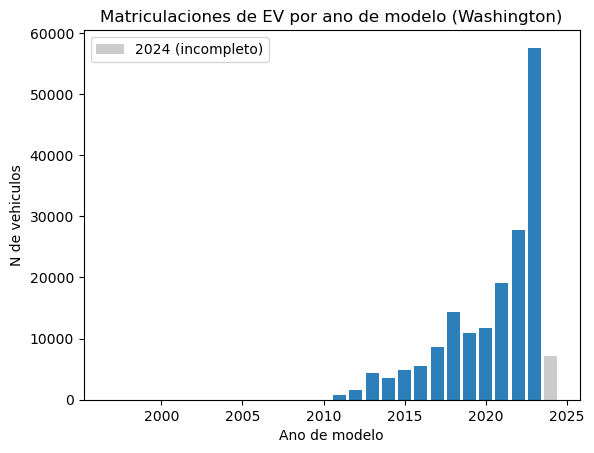

Ultimos anos:
year
2017     8561
2018    14322
2019    10939
2020    11768
2021    19132
2022    27776
2023    57587
2024     7080
Name: count, dtype: int64


In [39]:
ultimo = df["year"].max()
por_ano = df["year"].value_counts().sort_index()

plt.bar(por_ano.index, por_ano.values, color="#2c7fb8")
plt.bar(ultimo, por_ano.loc[ultimo], color="#cccccc",
        label=f"{ultimo} (incompleto)")
plt.title("Matriculaciones de EV por ano de modelo (Washington)")
plt.xlabel("Ano de modelo"); plt.ylabel("N de vehiculos"); plt.legend()
plt.show()

print("Ultimos anos:")
print(por_ano.tail(8))

La adopcion crece de forma exponencial , especialmente a partir del 2017. 

## 4. Composicion del mercado por segmentos

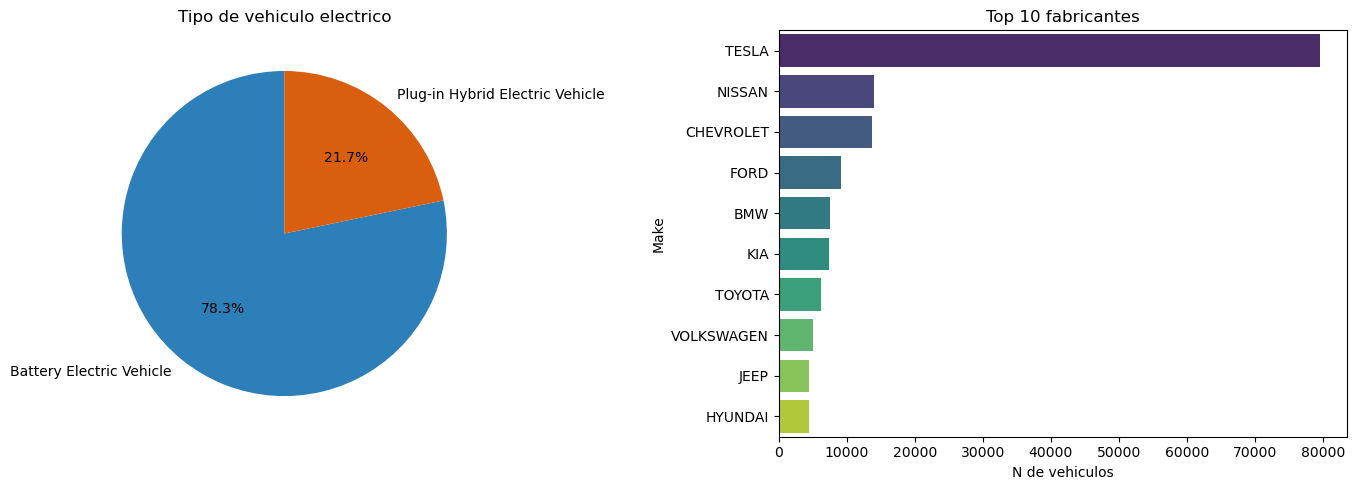

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 4.1 BEV vs PHEV
tipo = df["ev_type"].value_counts()
ax[0].pie(tipo, labels=tipo.index, autopct="%1.1f%%",
          colors=["#2c7fb8", "#d95f0e"], startangle=90)
ax[0].set_title("Tipo de vehiculo electrico")

# 4.2 Top 10 fabricantes
top_make = df["Make"].value_counts().head(10)
sns.barplot(x=top_make.values, y=top_make.index, ax=ax[1], palette="viridis", hue=top_make.index, legend=False)
ax[1].set_title("Top 10 fabricantes"); ax[1].set_xlabel("N de vehiculos")
plt.tight_layout(); plt.show()

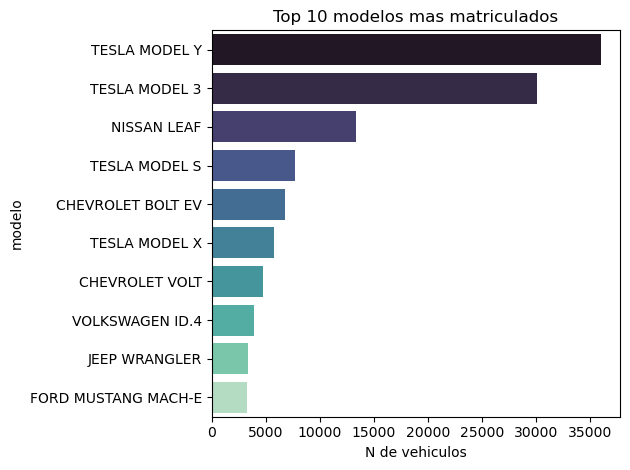

In [41]:
# Top 10 modelos
top_model = (df.assign(modelo=df["Make"] + " " + df["Model"])
               ["modelo"].value_counts().head(10))
sns.barplot(x=top_model.values, y=top_model.index, palette="mako", hue=top_model.index, legend=False)
plt.title("Top 10 modelos mas matriculados"); plt.xlabel("N de vehiculos")
plt.tight_layout(); plt.show()

### Distribucion geografica

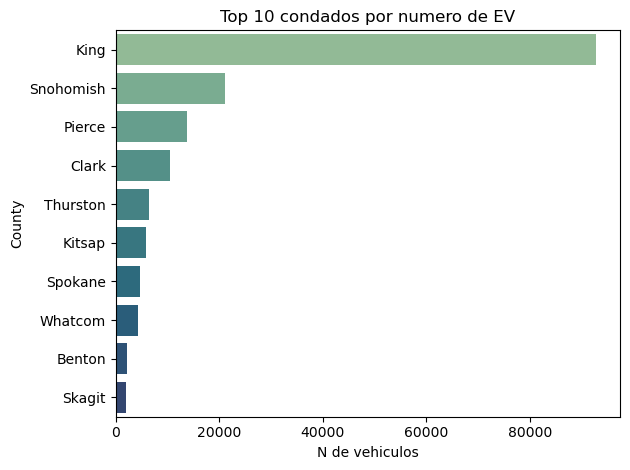

Cuota de los 3 mayores condados: 71.7% del total


In [42]:
top_county = df["County"].value_counts().head(10)
sns.barplot(x=top_county.values, y=top_county.index, palette="crest", hue=top_county.index, legend=False)
plt.title("Top 10 condados por numero de EV"); plt.xlabel("N de vehiculos")
plt.tight_layout(); plt.show()
print("Cuota de los 3 mayores condados: "
      f"{top_county.head(3).sum() / len(df) * 100:.1f}% del total")

## 5. Autonomia (Electric Range) y su evolucion

Muchos registros tienen `range_mi = 0` .Para el analisis de autonomia usamos solo los vehiculos con dato valido.

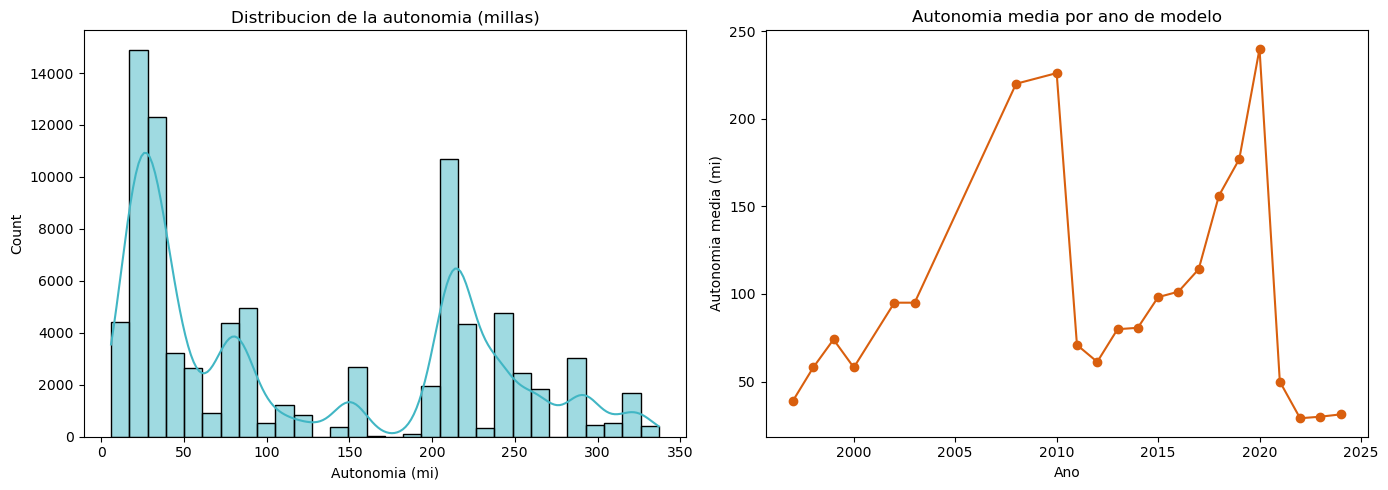

Autonomia media BEV: 196.3 mi
Autonomia media PHEV: 30.8 mi


In [43]:
con_rango = df[df["range_mi"] > 0]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(con_rango["range_mi"], bins=30, kde=True, color="#41b6c4", ax=ax[0])
ax[0].set_title("Distribucion de la autonomia (millas)")
ax[0].set_xlabel("Autonomia (mi)")

rango_ano = con_rango.groupby("year")["range_mi"].mean()
ax[1].plot(rango_ano.index, rango_ano.values, "-o", color="#d95f0e")
ax[1].set_title("Autonomia media por ano de modelo")
ax[1].set_xlabel("Ano"); ax[1].set_ylabel("Autonomia media (mi)")
plt.tight_layout(); plt.show()

print("Autonomia media BEV:",
      round(con_rango[con_rango.ev_type == "Battery Electric Vehicle"].range_mi.mean(), 1), "mi")
print("Autonomia media PHEV:",
      round(con_rango[con_rango.ev_type == "Plug-in Hybrid Electric Vehicle"].range_mi.mean(), 1), "mi")

## 6. Tamano de mercado y tasas de crecimiento

Calculamos el crecimiento interanual (YoY) y la tasa de crecimiento anual
compuesta (CAGR) sobre el periodo de expansion, excluyendo el ultimo ano
incompleto

In [44]:
serie = por_ano[por_ano.index < ultimo]          # excluimos el ano incompleto
serie = serie[serie.index >= 2011]               # era moderna del EV

yoy = serie.pct_change() * 100
tabla = pd.DataFrame({"matriculaciones": serie, "crecimiento_YoY_%": yoy.round(1)})
print(tabla.tail(10))

anos = serie.index.max() - serie.index.min()
cagr = (serie.iloc[-1] / serie.iloc[0]) ** (1 / anos) - 1
print(f"\nCAGR {serie.index.min()}-{serie.index.max()}: {cagr*100:.1f}% anual")

      matriculaciones  crecimiento_YoY_%
year                                    
2014             3509              -20.4
2015             4844               38.0
2016             5483               13.2
2017             8561               56.1
2018            14322               67.3
2019            10939              -23.6
2020            11768                7.6
2021            19132               62.6
2022            27776               45.2
2023            57587              107.3

CAGR 2011-2023: 43.2% anual


## 7. Prediccion del tamano de mercado

La serie crece de forma exponencial, asi que modelamos $\log(\text{matriculaciones})$ como una funcion lineal del año. Ajustamos sobre el periodo de expansion (2011 hasta el ultimo año completo) y proyectamos los proximos 5 añoss.

In [45]:
x = serie.index.values
y = serie.values

# Ajuste lineal en escala logaritmica  ->  log(y) = b*x + a
b, a = np.polyfit(x, np.log(y), 1)
def predecir(anio):
    return np.exp(a + b * anio)

r2 = np.corrcoef(x, np.log(y))[0, 1] ** 2
print(f"Modelo: matriculaciones ~ exp({a:.2f} + {b:.3f}*ano)   R2={r2:.3f}")
print(f"Crecimiento implicito: {(np.exp(b)-1)*100:.1f}% anual\n")

futuros = np.arange(x.min(), x.max() + 6)
pred = predecir(futuros)
prox = np.arange(x.max() + 1, x.max() + 6)
for yr in prox:
    print(f"Prediccion {yr}: {predecir(yr):,.0f} vehiculos")

Modelo: matriculaciones ~ exp(-569.08 + 0.287*ano)   R2=0.924
Crecimiento implicito: 33.2% anual

Prediccion 2024: 55,949 vehiculos
Prediccion 2025: 74,515 vehiculos
Prediccion 2026: 99,243 vehiculos
Prediccion 2027: 132,176 vehiculos
Prediccion 2028: 176,039 vehiculos


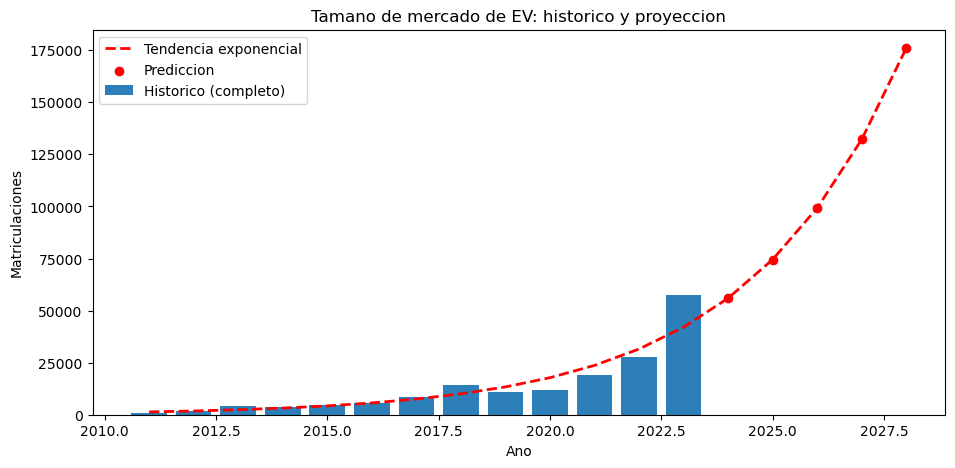

In [46]:
plt.figure(figsize=(11, 5))
plt.bar(serie.index, serie.values, color="#2c7fb8", label="Historico (completo)")
plt.plot(futuros, pred, "--", color="red", lw=2, label="Tendencia exponencial")
plt.scatter(prox, predecir(prox), color="red", zorder=5, label="Prediccion")
plt.title("Tamano de mercado de EV: historico y proyeccion")
plt.xlabel("Ano"); plt.ylabel("Matriculaciones"); plt.legend(); plt.show()

## 8. Modelo predictivo con red neuronal: estimacion de la autonomia

Como complemento al analisis de mercado, entrenamos una red neuronal que predice la autonomia (`Electric Range`) de un vehiculo a partir de
caracteristicas: el año de modelo, el tipo (BEV/PHEV) y el fabricante. Es un problema de regresion supervisada. Usamos solo los registros con autonomia informada (`range_mi > 0`).

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf

# Solo vehiculos con autonomia informada
dat = df[df["range_mi"] > 0].copy()

# Agrupamos los fabricantes minoritarios en "OTRO" para limitar las columnas
top_makes = dat["Make"].value_counts().head(10).index
dat["make_g"] = np.where(dat["Make"].isin(top_makes), dat["Make"], "OTRO")

# Variables predictoras (one-hot para las categoricas) y objetivo
X = pd.get_dummies(dat[["year", "ev_type", "make_g"]],
                   columns=["ev_type", "make_g"]).astype(float)
y = dat["range_mi"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler_nn = StandardScaler().fit(X_train)
X_train_s = scaler_nn.transform(X_train)
X_test_s = scaler_nn.transform(X_test)
print(f"Ejemplos: {len(dat):,} | Variables de entrada: {X.shape[1]}")

Ejemplos: 85,911 | Variables de entrada: 14


In [48]:
tf.random.set_seed(42)
red = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train_s.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1)            # salida continua: millas de autonomia
])
red.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
red.summary()

early = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
hist = red.fit(X_train_s, y_train, validation_split=0.15, epochs=200,
               batch_size=256, verbose=0, callbacks=[early])
print(f"Entrenamiento detenido en la epoca {len(hist.history['loss'])}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento detenido en la epoca 59


MAE : 7.7 millas
RMSE: 14.0 millas
R2  : 0.980


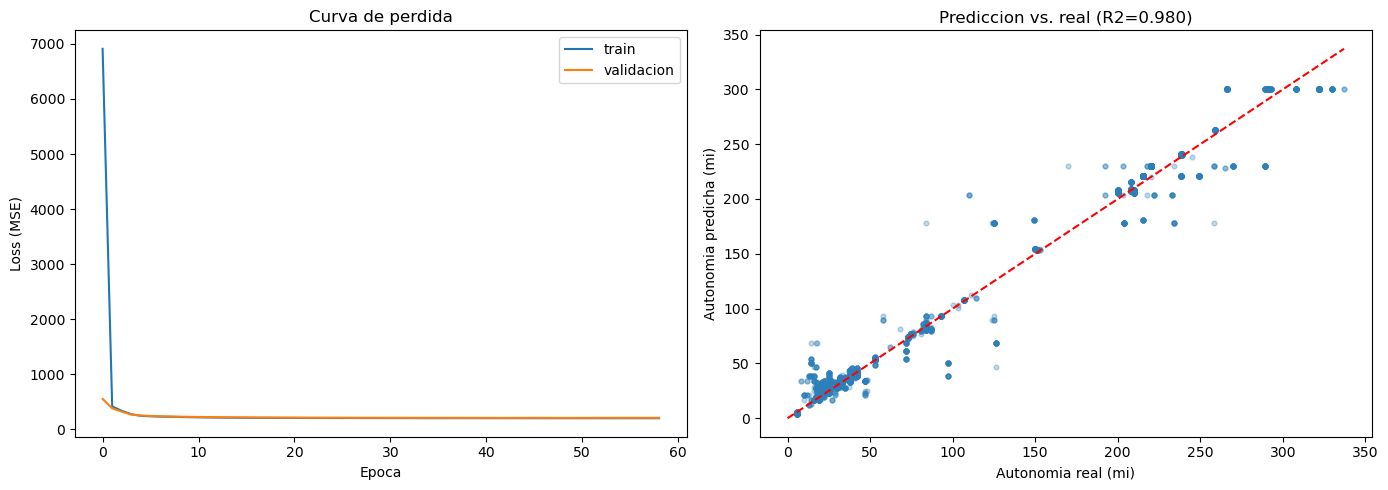

In [49]:
pred = red.predict(X_test_s, verbose=0).ravel()
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(((y_test - pred) ** 2).mean())
r2 = r2_score(y_test, pred)
print(f"MAE : {mae:.1f} millas")
print(f"RMSE: {rmse:.1f} millas")
print(f"R2  : {r2:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(hist.history["loss"], label="train")
ax[0].plot(hist.history["val_loss"], label="validacion")
ax[0].set_title("Curva de perdida"); ax[0].set_xlabel("Epoca")
ax[0].set_ylabel("Loss (MSE)"); ax[0].legend()

muestra = np.random.RandomState(0).choice(len(y_test), size=3000, replace=False)
ax[1].scatter(y_test[muestra], pred[muestra], alpha=0.3, s=12, color="#2c7fb8")
lims = [0, max(y_test.max(), pred.max())]
ax[1].plot(lims, lims, "--", color="red")
ax[1].set_title(f"Prediccion vs. real (R2={r2:.3f})")
ax[1].set_xlabel("Autonomia real (mi)"); ax[1].set_ylabel("Autonomia predicha (mi)")
plt.tight_layout(); plt.show()

### Interpretación

* La red predice la autonomia con un error medio de unas 7 millas y un R2 La razon es que, en este registro, la autonomia esta practicamente determinada por la combinacion fabricante + tipo + año, por lo que la red aprende casi una tabla de consulta

* Este modelo permitiria estimar la autonomia esperada de   nuevos modelos o completar los registros donde el dato falta 

## 9. Hallazgos principales


* El mercado de EV en Washington crece de forma **exponencial**, con una clara aceleracion desde 2017.
* El segmento **BEV** (electrico puro) domina ampliamente frente al **PHEV**, y la tendencia refuerza al BEV a medida que mejora la autonomia.
* El mercado esta muy concentrado,  Tesla lidera con gran diferencia y los 3 mayores condados (area de Seattle: King, Snohomish, Pierce) acumulan la mayor parte de las matriculaciones.
* La autonomia media de los modelos ha crecido con los años.
